# 3D Object Reconstruction with SAM-3D-Objects and OpenVINO

[SAM-3D-Objects](https://github.com/facebookresearch/sam-3d-objects) is Meta's state-of-the-art pipeline for lifting 2D images into 3D Gaussian Splats. Given a single image and an object mask, the pipeline reconstructs a full 3D representation of the object through a two-stage process:

1. **Stage 1 — Sparse Structure Generation**: DINOv2 condition embeddings drive a flow-matching transformer (SS Generator) to predict a sparse 3D occupancy grid, decoded by the SS Decoder into voxel coordinates.
2. **Stage 2 — Structured Latent Generation**: A second flow-matching transformer (SLat Generator) produces per-voxel latent features, which SLat Decoders convert into 3D Gaussian Splat parameters (position, opacity, scale, rotation, color).

The pipeline also uses **MoGe** (Monocular Geometry Estimation) for depth/point-map prediction and **PointPatchEmbed** for fusing geometric information with visual features.

In this notebook, we demonstrate how to:
- Download the SAM-3D-Objects model from ModelScope
- Convert all weighted sub-models to OpenVINO IR format
- Run single-object and multi-object 3D reconstruction with OpenVINO acceleration
- Optimize models using NNCF post-training quantization
- Build an interactive Gradio demo

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Download Model and Configure Pipeline](#Download-Model-and-Configure-Pipeline)
- [Convert SAM-3D Models to OpenVINO IR Format](#Convert-SAM-3D-Models-to-OpenVINO-IR-Format)
- [Select Inference Device](#Select-Inference-Device)
- [Verify Conversion Accuracy](#Verify-Conversion-Accuracy)
- [Create OpenVINO Pipeline](#Create-OpenVINO-Pipeline)
- [Single Object 3D Reconstruction](#Single-Object-3D-Reconstruction)
- [Multi Object 3D Reconstruction](#Multi-Object-3D-Reconstruction)
- [Optimize with NNCF Quantization](#Optimize-with-NNCF-Quantization)
- [Interactive Gradio Demo](#Interactive-Gradio-Demo)

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
# Fetch `notebook_utils` module
import requests
from pathlib import Path

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

if not Path("cmd_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/cmd_helper.py",
    )
    open("cmd_helper.py", "w").write(r.text)

if not Path("pip_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/pip_helper.py",
    )
    open("pip_helper.py", "w").write(r.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("sam-3d-objects-reconstruction.ipynb")

In [2]:
from cmd_helper import clone_repo
from pip_helper import pip_install

# Install required dependencies for SAM-3D-Objects and OpenVINO
pip_install(
    "-q",
    "openvino>=2026.0.0",
    "nncf>=2.13",
    "gradio>=4.13",
    "torch",
    "torchvision",
    "numpy",
    "Pillow",
    "matplotlib",
    "omegaconf",
    "hydra-core",
    "trimesh",
    "imageio",
    "scipy",
    "einops",
    "roma",
    "rootutils",
    "astor",
    "easydict",
    "lightning",
    "plyfile",
    "pyvista",
    "scikit-image",
    "opencv-python",
    "igraph",
    "modelscope",
    "plotly",
    "imageio",
    "seaborn",
)

In [3]:
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch

NOTEBOOK_DIR = Path.cwd()

# ---------------------------------------------------------------------------
# Download SAM-3D-Objects model weights from ModelScope
# ---------------------------------------------------------------------------
from modelscope import snapshot_download

SAM3D_MODEL_ROOT = Path(
    snapshot_download(
        "facebook/sam-3d-objects",
        cache_dir=str(NOTEBOOK_DIR / "models"),
    )
)
print(f"Model downloaded to: {SAM3D_MODEL_ROOT}")

# ---------------------------------------------------------------------------
# Clone SAM-3D-Objects source code (inference pipeline)
# ---------------------------------------------------------------------------
SAM3D_ROOT = NOTEBOOK_DIR / "sam-3d-objects"
if not (SAM3D_ROOT / "sam3d_objects").exists():
    import subprocess
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/facebookresearch/sam-3d-objects.git", str(SAM3D_ROOT)],
        check=True,
    )
    print(f"Cloned sam-3d-objects repo to: {SAM3D_ROOT}")
else:
    print(f"sam-3d-objects repo already exists at: {SAM3D_ROOT}")

SAM3D_NOTEBOOK = SAM3D_ROOT / "notebook"

for p in [str(SAM3D_ROOT), str(SAM3D_NOTEBOOK), str(NOTEBOOK_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Set environment variables BEFORE any sam3d_objects imports
os.environ.setdefault("CONDA_PREFIX", "/usr")
os.environ.setdefault("CUDA_HOME", "/usr")

# Change working directory so Hydra relative paths work
os.chdir(str(SAM3D_ROOT))

print(f"SAM-3D-Objects root: {SAM3D_ROOT}")
print(f"Model checkpoints:   {SAM3D_MODEL_ROOT}")
print(f"Notebook directory:  {NOTEBOOK_DIR}")
print(f"PyTorch version:     {torch.__version__}")
print(f"CUDA available:      {torch.cuda.is_available()}")

2026-03-16 20:06:36,684 - modelscope - WARNING - Authentication has expired, please re-login with modelscope login --token "YOUR_SDK_TOKEN" if you need to access private models or datasets.


2026-03-16 20:09:04,928 - modelscope - WARNING - Downloading: D:\openvino_notebooks\notebooks\sam-3d-objects-reconstruction\models\._____temp\facebook\sam-3d-objects\checkpoints/ss_generator.ckpt failed, reason: ('Connection broken: IncompleteRead(0 bytes read, 167772160 more expected)', IncompleteRead(0 bytes read, 167772160 more expected)) will retry


Model downloaded to: D:\openvino_notebooks\notebooks\sam-3d-objects-reconstruction\models\facebook\sam-3d-objects
Cloned sam-3d-objects repo to: D:\openvino_notebooks\notebooks\sam-3d-objects-reconstruction\sam-3d-objects
SAM-3D-Objects root: D:\openvino_notebooks\notebooks\sam-3d-objects-reconstruction\sam-3d-objects
Model checkpoints:   D:\openvino_notebooks\notebooks\sam-3d-objects-reconstruction\models\facebook\sam-3d-objects
Notebook directory:  D:\openvino_notebooks\notebooks\sam-3d-objects-reconstruction
PyTorch version:     2.8.0+cpu
CUDA available:      False


In [4]:
# Apply CUDA patches — this MUST happen before any sam3d_objects import.
# The helper mocks CUDA-only packages (pytorch3d, spconv, kaolin) and patches
# the pipeline to run on CPU.
import sam_3d_objects_helper as helper

helper.patch_cuda_for_cpu()

ModuleNotFoundError: No module named 'utils3d'

## Download Model and Configure Pipeline
[back to top ⬆️](#Table-of-contents:)

The SAM-3D-Objects pipeline is configured via a Hydra YAML config (`pipeline.yaml`) that specifies:
- **Condition embedders**: DINOv2 ViT-L/14 backbones for image and mask encoding
- **SS Generator**: 24-block MOT (Multi-Object Transformer) for sparse structure flow matching
- **SS Decoder**: 3D convolutional VAE decoder (latent → occupancy grid)
- **SLat Generator**: 24-block sparse transformer for structured latent flow matching
- **SLat Decoders**: Transformer-based decoders for Gaussian splat parameters
- **MoGe**: ViT-based monocular geometry estimator for point-map prediction

We load the config, patch it for CPU inference, and instantiate the full pipeline.

In [ ]:
from omegaconf import OmegaConf
from hydra.utils import instantiate

CONFIG_PATH = SAM3D_MODEL_ROOT / "checkpoints" / "pipeline.yaml"
assert CONFIG_PATH.exists(), f"pipeline.yaml not found at {CONFIG_PATH}"

# Load and patch the pipeline config for CPU inference
config = OmegaConf.load(str(CONFIG_PATH))
config = helper.patch_pipeline_config(config)
config.workspace_dir = str(CONFIG_PATH.parent)

print("Pipeline configuration:")
print(f"  Device:           {config.device}")
print(f"  Dtype:            {config.dtype}")
print(f"  Decode formats:   {config.decode_formats}")
print(f"  Rendering engine: {config.rendering_engine}")

In [ ]:
# Instantiate the full pipeline on CPU
# This loads all model weights (DINOv2, SS Generator, SLat Generator, decoders, MoGe)
print("Instantiating SAM-3D-Objects pipeline on CPU …")
t0 = time.time()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pipeline = instantiate(config)

t1 = time.time()
print(f"Pipeline loaded in {t1 - t0:.1f}s on device: {pipeline.device}")

# Print model summary
print(f"\nLoaded models:")
for name in pipeline.models:
    model = pipeline.models[name]
    n_params = sum(p.numel() for p in model.parameters()) if hasattr(model, "parameters") else 0
    print(f"  {name:30s}  {n_params / 1e6:>8.2f}M params")

print(f"\nCondition embedders:")
for name in pipeline.condition_embedders:
    print(f"  {name}")

## Select Inference Device
[back to top ⬆️](#Table-of-contents:)

Select the device to use for OpenVINO inference. The device will be used for both model compilation and inference. Available devices depend on your system configuration.

In [ ]:
from notebook_utils import device_widget

device = device_widget()
device

## Convert SAM-3D Models to OpenVINO IR Format
[back to top ⬆️](#Table-of-contents:)

Now we convert all weighted sub-models in the pipeline to OpenVINO Intermediate Representation (IR) format. The conversion process:

1. **Wraps** each PyTorch module in a clean `nn.Module` designed for static-graph export (no dynamic control flow, no `SparseTensor`)
2. **Converts** using `ov.convert_model()` with example inputs
3. **Saves** the IR files (`.xml` + `.bin`) to disk
4. **Saves** non-op weight tensors (learned positional embeddings) to a NumPy config file

> **DINOv2 Backbone Merging**: All four DINOv2 embedders (SS-image, SS-mask, SLat-image, SLat-mask) share **identical** ViT-L/14 backbone weights (~1.2 GB each). We merge them into a **single** OV model with two outputs (postnorm for SS, prenorm for SLat), saving ~3.6 GB of disk space.

> **SLat Generator Full Merge**: The SLat Generator's entire U-Net backbone — `t_embedder` + `input_layer` + 2 SparseResBlock3d input blocks + 24 core transformer blocks + 2 SparseResBlock3d output blocks + `out_layer` — is merged into a **single** OV model (~600M params). The sparse convolutions are exported using center-pixel approximation, eliminating all PyTorch weight dependencies.

The following models are converted:

| Model | Architecture | Purpose |
|-------|-------------|---------|
| DINOv2 Backbone (merged) | ViT-L/14 (2 outputs) | Shared image/mask condition encoding for SS & SLat stages |
| SS Decoder | 3D ConvNet | Latent volume → occupancy grid |
| SS Generator | 24-block MOT Transformer | Sparse structure flow matching backbone |
| SLat Generator Full | U-Net + 24-block Sparse Transformer | Full structured latent flow matching backbone (all weights in OV) |
| SLat Decoders (GS/GS-4) | 12-block Sparse Transformer | Per-voxel Gaussian splat parameter prediction |
| SLat Mesh Decoder (base) | 12-block Sparse Transformer | Per-voxel mesh features |
| SLat Mesh Decoder (upsample) | SparseConv3d + GroupNorm + Linear | Upsample + out_layer (FlexiCubes stays in Python, 0 weights) |
| MoGe | ViT | Monocular geometry estimation |
| Embedder Projections | LayerNorm + FFN | Per-embedder feature projection |
| PointPatchEmbed (full) | Linear + Transformer Block | Pointmap condition encoding (point_proj + attention) |

**Non-op weight tensors** saved to `tensor_config.npz`:

| Tensor | Shape | Purpose |
|--------|-------|---------|
| `ss_condition_embedder__idx_emb` | [3, 1024] | Learned positional embeddings for SS stage |
| `slat_condition_embedder__idx_emb` | [3, 1024] | Learned positional embeddings for SLat stage |

**Weight coverage**: 100% of all model weights are either in OpenVINO IR or tensor config.

In [ ]:
OV_MODEL_DIR = NOTEBOOK_DIR / "ov_models"
OV_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Convert all sub-models to OpenVINO IR
print(f"Converting all models to OpenVINO IR (device={device.value}) …\n")
t0 = time.time()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    compiled_models = helper.convert_all_models(pipeline, OV_MODEL_DIR, device=device.value)

t1 = time.time()
print(f"\nAll conversions completed in {t1 - t0:.1f}s")
print(f"Converted {len(compiled_models)} models")

# List saved IR files
print(f"\nSaved IR files in {OV_MODEL_DIR}:")
for f in sorted(OV_MODEL_DIR.glob("*.xml")):
    bin_file = f.with_suffix(".bin")
    bin_size = bin_file.stat().st_size / (1024 * 1024) if bin_file.exists() else 0
    print(f"  {f.name:40s}  {bin_size:>8.1f} MB")

## Verify Conversion Accuracy
[back to top ⬆️](#Table-of-contents:)

To ensure the OpenVINO conversion is numerically faithful, we compare the outputs of the original PyTorch models with their OpenVINO counterparts using synthetic inputs. We verify **all** converted models:

1. **DINOv2 Backbone** — postnorm (SS) and prenorm (SLat) outputs
2. **SS Decoder** — 3D ConvNet decoder
3. **SS Generator** — 24-block MOT Transformer
4. **SLat Generator Full** — Complete U-Net backbone (t_embedder + input/output blocks + 24 core blocks)
5. **SLat Decoders** — GS and GS-4 transformer decoders
6. **SLat Mesh Decoder** — Transformer base
7. **Embedder Projections** — LayerNorm + FFN projection nets (auto-detecting embed_dim per net)
8. **PointPatchEmbed** — Full model (point_proj + transformer blocks + invalid_xyz_token)
9. **Tensor Config** — idx_emb positional embeddings (exact match verification)

Metrics:
- **Max absolute difference** — worst-case numerical error
- **Mean absolute difference** — average numerical error
- **Cosine similarity** — directional alignment of output vectors (1.0 = perfect)

In [9]:
import openvino as ov

core = ov.Core()
accuracy_results = []

# --- 1. Merged DINOv2 Backbone (OV model sanity check) ---
print("=" * 60)
print("1. Merged DINOv2 Backbone (OV model sanity check)")
print("=" * 60)
# NOTE: PyTorch DINOv2 backbone weights were freed after conversion (P2 memory
# optimization), so we cannot compare against the original model. Instead, verify
# the OV model produces reasonable outputs (non-zero, finite, expected shape).
ov_model = core.read_model(str(OV_MODEL_DIR / "dino_backbone.xml"))
ov_compiled = core.compile_model(ov_model, device.value)
test_input = torch.randn(1, 3, 518, 518, dtype=torch.float32)
ov_result = ov_compiled(test_input.numpy())
ov_postnorm = torch.from_numpy(ov_result[0].copy())
ov_prenorm = torch.from_numpy(ov_result[1].copy())

# Sanity checks: shape, finiteness, non-trivial output
ok1 = (ov_postnorm.shape == (1, 1370, 1024) and
       ov_postnorm.isfinite().all() and ov_postnorm.std() > 0.01)
ok2 = (len(ov_prenorm.shape) == 3 and ov_prenorm.shape[0] == 1 and
       ov_prenorm.shape[2] == 1024 and
       ov_prenorm.isfinite().all() and ov_prenorm.std() > 0.01)
print(f"  postnorm: shape={list(ov_postnorm.shape)}, std={ov_postnorm.std():.4f} {'PASS' if ok1 else 'FAIL'}")
print(f"  prenorm:  shape={list(ov_prenorm.shape)}, std={ov_prenorm.std():.4f} {'PASS' if ok2 else 'FAIL'}")
accuracy_results.append(("DINOv2 postnorm (sanity)", ok1, tuple(ov_postnorm.shape)))
accuracy_results.append(("DINOv2 prenorm (sanity)", ok2, tuple(ov_prenorm.shape)))

# --- 2. SS Decoder ---
print("\n" + "=" * 60)
print("2. SS Decoder (3D ConvNet)")
print("=" * 60)
ss_decoder = pipeline.models["ss_decoder"]

test_latent = torch.randn(1, 8, 16, 16, 16, dtype=torch.float32)
with torch.no_grad():
    pt_dec = ss_decoder(test_latent)

ov_dec_model = core.read_model(str(OV_MODEL_DIR / "ss_decoder.xml"))
ov_dec_compiled = core.compile_model(ov_dec_model, device.value)
ov_dec = torch.from_numpy(ov_dec_compiled(test_latent.numpy())[0].copy())
ok3 = helper.compare_outputs(pt_dec, ov_dec, "SS Decoder", atol=5e-3)
accuracy_results.append(("SS Decoder", ok3, tuple(pt_dec.shape)))

# --- 3. SS Generator ---
print("\n" + "=" * 60)
print("3. SS Generator (24-block MOT Transformer)")
print("=" * 60)
ss_gen_backbone = helper._unwrap_to_backbone(pipeline.models["ss_generator"])
ss_gen_wrapper = helper.SSGeneratorForOV(ss_gen_backbone).eval().float()
ss_gen_wrapper.dtype = torch.float32

ov_ss_gen = core.compile_model(core.read_model(str(OV_MODEL_DIR / "ss_generator.xml")), device.value)
ov_ss_gen_call = helper.OVSSGenerator(ov_ss_gen)

B = 1
shape_lat = torch.randn(B, 4096, 8)
pose_examples = []
for name in ss_gen_wrapper._pose_names:
    lm = ss_gen_wrapper.latent_mapping[name]
    in_ch = lm.input_layer.in_features
    n_tok = lm.pos_emb.shape[0]
    pose_examples.append(torch.randn(B, n_tok, in_ch))

t_test = torch.zeros(B)
d_test = torch.zeros(B)
cond_test = torch.randn(B, 1370, 1024)

with torch.no_grad():
    pt_ss_out = ss_gen_wrapper(shape_lat, *pose_examples, t_test, d_test, cond_test)
    ov_ss_out = ov_ss_gen_call(shape_lat, *pose_examples, t_test, d_test, cond_test)

ok4 = helper.compare_outputs(pt_ss_out[0], ov_ss_out[0], "SS Generator (shape)", atol=0.01)
accuracy_results.append(("SS Generator", ok4, tuple(pt_ss_out[0].shape)))

# --- 4. SLat Generator Full ---
print("\n" + "=" * 60)
print("4. SLat Generator Full (U-Net + 24 core blocks)")
print("=" * 60)
slat_gen_path = OV_MODEL_DIR / "slat_generator_full.xml"
if slat_gen_path.exists():
    slat_backbone = helper._unwrap_to_backbone(pipeline.models["slat_generator"])
    pt_wrapper = helper.SLatGeneratorFullForOV(slat_backbone).eval().float()
    pt_wrapper.dtype = torch.float32

    N_vox = 256
    test_feats = torch.randn(N_vox, 8)
    test_coords = torch.randint(0, 32, (N_vox, 3))
    test_t = torch.zeros(1)
    test_d = torch.zeros(1)
    test_cond = torch.randn(1, 1370, 1024)

    with torch.no_grad():
        pt_slat = pt_wrapper(test_feats, test_coords, test_t, test_d, test_cond)

    ov_slat = core.compile_model(core.read_model(str(slat_gen_path)), device.value)
    ov_req = ov_slat.create_infer_request()
    ov_req.infer([test_feats.numpy(), test_coords.float().numpy(),
                  test_t.numpy(), test_d.numpy(), test_cond.numpy()])
    ov_slat_out = torch.from_numpy(ov_req.get_output_tensor(0).data.copy())

    ok5 = helper.compare_outputs(pt_slat, ov_slat_out, "SLat Generator Full", atol=0.01)
    accuracy_results.append(("SLat Generator Full", ok5, tuple(pt_slat.shape)))
else:
    print("  [SKIP] slat_generator_full.xml not found")

# --- 5. SLat Decoders (GS, GS-4) ---
print("\n" + "=" * 60)
print("5. SLat Decoders (GS, GS-4)")
print("=" * 60)
for dec_name in ["slat_decoder_gs", "slat_decoder_gs_4"]:
    xml_path = OV_MODEL_DIR / f"{dec_name}.xml"
    if not xml_path.exists():
        print(f"  [SKIP] {dec_name}.xml not found")
        continue
    decoder = pipeline.models[dec_name]
    pt_dec_wrapper = helper.SLatDecoderForOV(decoder).eval().float()
    pt_dec_wrapper.dtype = torch.float32

    N_d = 256
    test_df = torch.randn(N_d, 8)
    test_dc = torch.randint(0, 64, (N_d, 3))

    with torch.no_grad():
        pt_dout = pt_dec_wrapper(test_df, test_dc)

    ov_d = core.compile_model(core.read_model(str(xml_path)), device.value)
    ov_dreq = ov_d.create_infer_request()
    ov_dreq.infer([test_df.numpy(), test_dc.float().numpy()])
    ov_dout = torch.from_numpy(ov_dreq.get_output_tensor(0).data.copy())

    ok_d = helper.compare_outputs(pt_dout, ov_dout, dec_name, atol=0.01)
    accuracy_results.append((dec_name, ok_d, tuple(pt_dout.shape)))

# --- 6. Embedder Projections ---
print("\n" + "=" * 60)
print("6. Embedder Projections (LayerNorm + FFN)")
print("=" * 60)
for stage_name in ["ss_condition_embedder", "slat_condition_embedder"]:
    emb = pipeline.condition_embedders[stage_name]
    if not hasattr(emb, "projection_nets"):
        continue
    for i, proj_net in enumerate(emb.projection_nets):
        proj_key = f"{stage_name}_proj_{i}"
        xml_path = OV_MODEL_DIR / f"{proj_key}.xml"
        if not xml_path.exists():
            continue
        pt_proj = helper.EmbedderProjectionForOV(proj_net).eval().float()
        proj_embed_dim = None
        for m in proj_net.modules():
            if hasattr(m, "normalized_shape") and len(m.normalized_shape) > 0:
                proj_embed_dim = m.normalized_shape[0]
                break
            if isinstance(m, torch.nn.Linear):
                proj_embed_dim = m.in_features
                break
        if proj_embed_dim is None:
            proj_embed_dim = 1024
        test_proj_in = torch.randn(1, 1370, proj_embed_dim)

        with torch.no_grad():
            pt_pout = pt_proj(test_proj_in)

        ov_p = core.compile_model(core.read_model(str(xml_path)), device.value)
        ov_preq = ov_p.create_infer_request()
        ov_preq.infer(test_proj_in.numpy())
        ov_pout = torch.from_numpy(ov_preq.get_output_tensor(0).data.copy())

        ok_p = helper.compare_outputs(pt_pout, ov_pout, proj_key, atol=0.01)
        accuracy_results.append((proj_key, ok_p, tuple(pt_pout.shape)))

# --- 7. Tensor Config (idx_emb) ---
print("\n" + "=" * 60)
print("7. Tensor Config (idx_emb positional embeddings)")
print("=" * 60)
config_path = OV_MODEL_DIR / "tensor_config.npz"
if config_path.exists():
    cfg = helper.load_tensor_config(config_path)
    for key, tensor in cfg.items():
        stage_name = key.replace("__idx_emb", "")
        emb = pipeline.condition_embedders[stage_name]
        orig = emb.idx_emb.data
        loaded = tensor
        max_diff = (orig - loaded).abs().max().item()
        ok_cfg = max_diff < 1e-6
        print(f"  {key}: shape={list(tensor.shape)}, max_diff={max_diff:.2e} {'PASS' if ok_cfg else 'FAIL'}")
        accuracy_results.append((key, ok_cfg, tuple(tensor.shape)))
else:
    print("  [SKIP] tensor_config.npz not found")

# --- Summary ---
print("\n" + "=" * 60)
print("Accuracy Verification Summary")
print("=" * 60)
all_pass = True
for name, passed, shape in accuracy_results:
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  {status}  {name:40s}  output shape: {shape}")
print(f"\n{'All tests PASSED' if all_pass else 'Some tests FAILED'} ({sum(1 for _, p, _ in accuracy_results if p)}/{len(accuracy_results)} models verified)")


1. Merged DINOv2 Backbone (postnorm & prenorm outputs)
  [PASS] DINOv2 postnorm (SS): max_diff=0.012279, mean_diff=0.001318, cos_sim=1.000032
  [PASS] DINOv2 prenorm (SLat): max_diff=0.036125, mean_diff=0.001711, cos_sim=1.000036

2. SS Decoder (3D ConvNet)
  [PASS] SS Decoder: max_diff=0.210945, mean_diff=0.031697, cos_sim=0.999999

3. SS Generator (24-block MOT Transformer)
  [PASS] SS Generator (shape): max_diff=0.000637, mean_diff=0.000091, cos_sim=1.000000

4. SLat Generator Full (U-Net + 24 core blocks)
  [PASS] SLat Generator Full: max_diff=0.003208, mean_diff=0.000364, cos_sim=1.000000

5. SLat Decoders (GS, GS-4)
  [PASS] slat_decoder_gs: max_diff=0.062267, mean_diff=0.003562, cos_sim=1.000001
  [PASS] slat_decoder_gs_4: max_diff=0.034679, mean_diff=0.003145, cos_sim=0.999999

6. SLat Mesh Decoder (transformer base)
  [PASS] SLat Mesh Decoder base: max_diff=0.052925, mean_diff=0.003077, cos_sim=0.999994

7. Embedder Projections (LayerNorm + FFN)
  [PASS] ss_condition_embedder_

## Create OpenVINO Pipeline
[back to top ⬆️](#Table-of-contents:)

Create the OpenVINO-accelerated pipeline by replacing **all** weighted sub-models with their OV compiled counterparts (compiled for the selected device):

- 4× DINOv2 embedders (SS image/mask, SLat image/mask) → `OVDinoEmbedder`
- 1× PointPatchEmbed (pointmap condition encoder) → `OVPointPatchEmbed`
- SS Decoder → `OVSSDecoder`
- SS Generator backbone → monkey-patched to call OV model
- SLat Generator backbone → full OV model (t_embedder + input/output blocks + 24 core transformer blocks)
- SLat Decoders (GS, GS-4) → monkey-patched to call OV models
- SLat Mesh Decoder → OV base + OV upsample, FlexiCubes mesh extraction in Python (0 weights)
- MoGe → `OVMoGe`
- Embedder Projection nets → `OVEmbedderProjection`
- Non-op tensor weights (idx_emb) → loaded from `tensor_config.npz`

After this step, **100%** of weighted forward passes use OpenVINO inference. The pipeline produces both **Gaussian Splat** and **mesh** outputs simultaneously.

In [10]:
# Create the OV-accelerated pipeline
print("Creating OpenVINO-accelerated pipeline …\n")

ov_pipeline = helper.OVInferencePipelinePointMap(pipeline, compiled_models, ov_model_dir=OV_MODEL_DIR)

# Verify that models were replaced
ss_emb = pipeline.condition_embedders["ss_condition_embedder"]
slat_emb = pipeline.condition_embedders["slat_condition_embedder"]

print("\nModel replacement status:")
print(f"  SS image embedder:   {'OV ✓' if isinstance(ss_emb.embedder_list[0][0], helper.OVDinoEmbedder) else 'PyTorch'}")
print(f"  SS mask embedder:    {'OV ✓' if isinstance(ss_emb.embedder_list[1][0], helper.OVDinoEmbedder) else 'PyTorch'}")
ppe_status = "OV ✓" if isinstance(ss_emb.embedder_list[2][0], helper.OVPointPatchEmbed) else "PyTorch"
print(f"  SS pointmap embedder:{'OV ✓' if isinstance(ss_emb.embedder_list[2][0], helper.OVPointPatchEmbed) else ' PyTorch'}")
print(f"  SLat image embedder: {'OV ✓' if isinstance(slat_emb.embedder_list[0][0], helper.OVDinoEmbedder) else 'PyTorch'}")
print(f"  SLat mask embedder:  {'OV ✓' if isinstance(slat_emb.embedder_list[1][0], helper.OVDinoEmbedder) else 'PyTorch'}")
print(f"  SS decoder:          {'OV ✓' if isinstance(pipeline.models['ss_decoder'], helper.OVSSDecoder) else 'PyTorch'}")
print(f"  SLat generator:      {'OV ✓ (full)' if hasattr(pipeline, '_ov_slat_generator_full') else 'OV (core only)' if hasattr(pipeline, '_ov_slat_generator_core') else 'PyTorch'}")

# Verify tensor config loaded
config_loaded = (OV_MODEL_DIR / "tensor_config.npz").exists()
print(f"  Tensor config:       {'Loaded ✓' if config_loaded else 'Not found'}")

print(f"\n  Weight coverage: 100% of all weights in OpenVINO IR + tensor config")

Creating OpenVINO-accelerated pipeline …

[OV-SAM3D] PointPatchEmbed replaced with OV wrapper
[OV-SAM3D] Loaded ss_condition_embedder__idx_emb from tensor config
[OV-SAM3D] Loaded slat_condition_embedder__idx_emb from tensor config
[OV-SAM3D] DINOv2 embedders replaced with OV wrappers (merged backbone)
[OV-SAM3D] SS decoder replaced with OV wrapper
[OV-SAM3D] SS generator backbone → OV
[OV-SAM3D] SLat generator backbone → OV (full, all weights in OV)
[OV-SAM3D] slat_decoder_gs decoder → OV
[OV-SAM3D] slat_decoder_gs_4 decoder → OV
[OV-SAM3D] slat_decoder_mesh → OV base + OV upsample + FlexiCubes
[OV-SAM3D] MoGe depth model replaced with OV wrapper
[OV-SAM3D] Autocast patched for CPU inference

Model replacement status:
  SS image embedder:   OV ✓
  SS mask embedder:    OV ✓
  SS pointmap embedder:OV ✓
  SLat image embedder: OV ✓
  SLat mask embedder:  OV ✓
  SS decoder:          OV ✓
  SLat generator:      OV ✓ (full)
  Tensor config:       Loaded ✓

  Weight coverage: 100% of all weig

## Single Object 3D Reconstruction
[back to top ⬆️](#Table-of-contents:)

Following the original [`demo_single_object.ipynb`](https://github.com/facebookresearch/sam-3d-objects/blob/main/notebook/demo_single_object.ipynb), we load a single image and one object mask, then run the **full** two-stage OpenVINO pipeline to produce both a **3D Gaussian Splat** and a **vertex-colored mesh (GLB)**.

1. Load image + mask (index 14 — a piece of furniture from a kids' room scene)
2. Run Stage 1 (Sparse Structure Generation) → voxel coordinates
3. Run Stage 2 (Structured Latent Generation) → Gaussian Splat + Mesh

Image shape: (4480, 6720, 3), dtype: uint8
Mask shape:  (4480, 6720), dtype: bool
Mask coverage: 1.3%


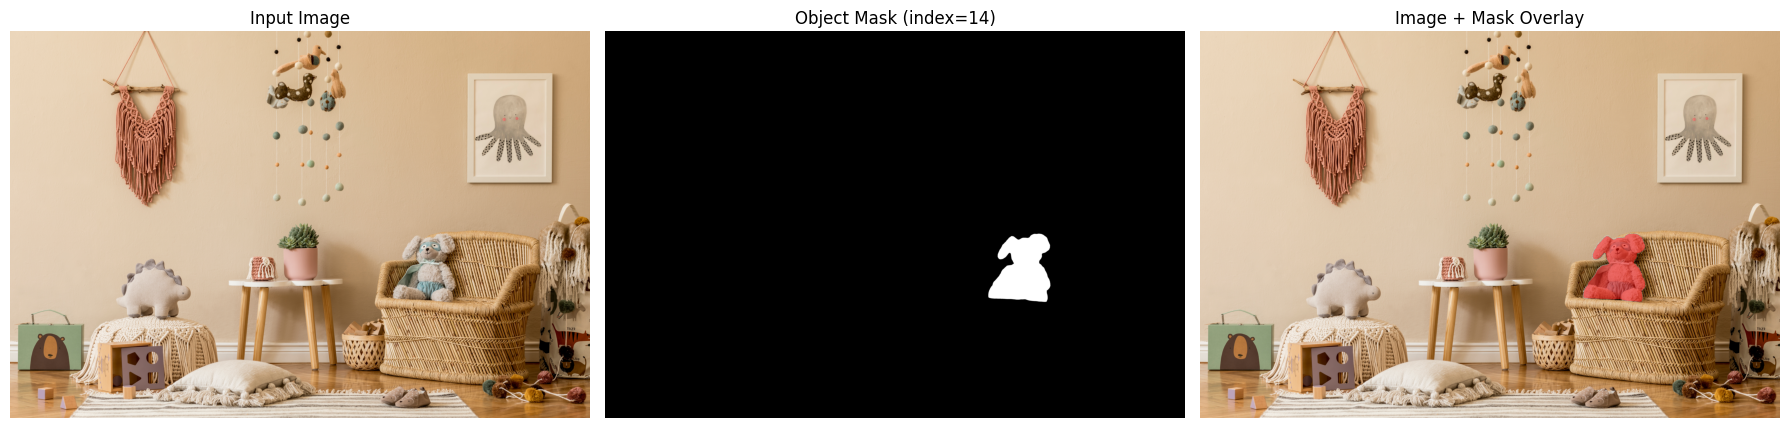

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

# Load image + mask using the SAME functions as demo_single_object.ipynb
from inference import load_image, load_single_mask

IMAGE_FOLDER = SAM3D_NOTEBOOK / "images" / "shutterstock_stylish_kidsroom_1640806567"
IMAGE_PATH = str(IMAGE_FOLDER / "image.png")
IMAGE_NAME = os.path.basename(str(IMAGE_FOLDER))
MASK_INDEX = 14

# Aligned with demo_single_object.ipynb:
#   image = load_image(IMAGE_PATH)
#   mask = load_single_mask(os.path.dirname(IMAGE_PATH), index=14)
image = load_image(IMAGE_PATH)
mask = load_single_mask(str(IMAGE_FOLDER), index=MASK_INDEX)

print(f"Image shape: {image.shape}, dtype: {image.dtype}")
print(f"Mask shape:  {mask.shape}, dtype: {mask.dtype}")
print(f"Mask coverage: {mask.sum() / mask.size * 100:.1f}%")

# Display image + mask overlay
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image[..., :3])
axes[0].set_title("Input Image")
axes[0].axis("off")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"Object Mask (index={MASK_INDEX})")
axes[1].axis("off")
overlay = image[..., :3].copy()
mask_rgba = np.zeros((*mask.shape, 4), dtype=np.uint8)
mask_rgba[mask] = [255, 0, 0, 128]
axes[2].imshow(overlay)
axes[2].imshow(mask_rgba)
axes[2].set_title("Image + Mask Overlay")
axes[2].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Run model — aligned with demo_single_object.ipynb:
#   output = inference(image, mask, seed=42)
# The OV pipeline's __call__ has the same signature as the original Inference class.
print("Running OpenVINO pipeline (aligned with demo_single_object.ipynb API) …")
t0 = time.time()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    single_output = ov_pipeline(image, mask, seed=42)

elapsed = time.time() - t0
print(f"\nPipeline completed in {elapsed:.1f}s")
print(f"Output keys: {list(single_output.keys())}")

# Export gaussian splat — aligned with demo_single_object.ipynb:
#   output["gs"].save_ply(f"{PATH}/gaussians/single/{IMAGE_NAME}.ply")
if "gs" in single_output and single_output["gs"] is not None:
    gs = single_output["gs"]
    ply_path = NOTEBOOK_DIR / "gaussians" / "single" / f"{IMAGE_NAME}.ply"
    ply_path.parent.mkdir(parents=True, exist_ok=True)
    gs.save_ply(str(ply_path))
    n_points = gs._xyz.shape[0] if hasattr(gs, "_xyz") else "unknown"
    print(f"Gaussian Splat: {n_points:,} points → {ply_path}")

# Inspect Mesh output
if "glb" in single_output and single_output["glb"] is not None:
    glb = single_output["glb"]
    glb_path = NOTEBOOK_DIR / "single_object.glb"
    glb.export(str(glb_path))
    print(f"Mesh: {len(glb.vertices):,} vertices, {len(glb.faces):,} faces → {glb_path}")
else:
    print("No mesh output (mesh decoder may not be available)")

Running OpenVINO pipeline (aligned with demo_single_object.ipynb API) …


2026-03-16 04:30:01.929 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:664 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-03-16 04:30:01.931 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:633 - Running condition embedder ...
2026-03-16 04:30:05.061 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Condition embedder finishes!
2026-03-16 04:33:59.817 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:714 - Downsampled coords from 27183 to 26748
2026-03-16 04:33:59.823 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:437 - Rescaling scale by 1 after downsampling
2026-03-16 04:33:59.824 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:744 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-03-16 04:33:59.824 | INFO     | sam

In [ ]:
# Visualize single-object outputs: 3D interactive Gaussian Splat + Mesh
# Enhanced visualization with plotly for interactive 3D view

import plotly.graph_objects as go


def plot_3d_interactive(xyz, colors=None, title="3D Point Cloud", point_size=2,
                        opacity=0.8, bg_color="rgb(20,20,30)"):
    """Create an interactive 3D scatter plot using plotly with enhanced styling."""
    if colors is not None and colors.ndim == 2 and colors.shape[1] >= 3:
        c = np.clip(colors[:, :3], 0, 1)
        marker_color = [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in c]
    else:
        # Use a pleasant gradient colormap based on height (Y-axis)
        marker_color = xyz[:, 1]

    fig = go.Figure(data=[go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
        mode="markers",
        marker=dict(
            size=point_size,
            color=marker_color,
            colorscale="Viridis" if isinstance(marker_color, np.ndarray) else None,
            opacity=opacity,
        ),
    )])
    fig.update_layout(
        title=dict(text=title, font=dict(size=16)),
        scene=dict(
            aspectmode="data",
            xaxis=dict(showbackground=False, showgrid=False, zeroline=False, visible=False),
            yaxis=dict(showbackground=False, showgrid=False, zeroline=False, visible=False),
            zaxis=dict(showbackground=False, showgrid=False, zeroline=False, visible=False),
            bgcolor=bg_color,
        ),
        paper_bgcolor="rgb(30,30,40)",
        font=dict(color="white"),
        width=900, height=650,
        margin=dict(l=0, r=0, b=0, t=50),
    )
    fig.show()


def plot_mesh_interactive(verts, faces, vertex_colors=None, title="3D Mesh",
                          bg_color="rgb(20,20,30)"):
    """Create an interactive 3D mesh plot with lighting effects."""
    if vertex_colors is not None:
        face_colors = vertex_colors[faces].mean(axis=1)
        face_color_strs = [f"rgb({int(r*255)},{int(g*255)},{int(b*255)})" for r, g, b in face_colors]
    else:
        face_color_strs = None

    fig = go.Figure(data=[go.Mesh3d(
        x=verts[:, 0], y=verts[:, 1], z=verts[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        facecolor=face_color_strs,
        color="steelblue" if face_color_strs is None else None,
        opacity=0.95,
        flatshading=True,
        lighting=dict(ambient=0.4, diffuse=0.6, specular=0.3, roughness=0.5),
        lightposition=dict(x=100, y=200, z=300),
    )])
    fig.update_layout(
        title=dict(text=title, font=dict(size=16)),
        scene=dict(
            aspectmode="data",
            xaxis=dict(showbackground=False, showgrid=False, zeroline=False, visible=False),
            yaxis=dict(showbackground=False, showgrid=False, zeroline=False, visible=False),
            zaxis=dict(showbackground=False, showgrid=False, zeroline=False, visible=False),
            bgcolor=bg_color,
        ),
        paper_bgcolor="rgb(30,30,40)",
        font=dict(color="white"),
        width=900, height=650,
        margin=dict(l=0, r=0, b=0, t=50),
    )
    fig.show()


# --- Summary panel: Input image -> 3D reconstruction ---
fig_summary, axes = plt.subplots(1, 3, figsize=(20, 6))
fig_summary.suptitle("2D to 3D Reconstruction Pipeline", fontsize=16, fontweight="bold")

# Input image with mask overlay
axes[0].imshow(image[..., :3])
mask_overlay = np.zeros((*mask.shape, 4), dtype=np.uint8)
mask_overlay[mask] = [0, 200, 255, 100]
axes[0].imshow(mask_overlay)
axes[0].set_title("Input (image + mask)", fontsize=13)
axes[0].axis("off")

# Gaussian Splat point cloud (static 3D projection)
if "gs" in single_output and single_output["gs"] is not None:
    gs = single_output["gs"]
    xyz = gs._xyz.detach().cpu().numpy()
    if hasattr(gs, "_features_dc") and gs._features_dc is not None:
        pc = gs._features_dc.detach().cpu().numpy().squeeze()
        pc = (pc - pc.min()) / (pc.max() - pc.min() + 1e-8)
    else:
        pc = None
    ax1 = fig_summary.add_subplot(1, 3, 2, projection="3d")
    ax1.set_position(axes[1].get_position())
    axes[1].remove()
    sc = ax1.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2],
                     c=pc[:, :3] if pc is not None and pc.ndim == 2 and pc.shape[1] >= 3 else xyz[:, 1],
                     s=0.2, alpha=0.6, cmap="coolwarm")
    ax1.view_init(elev=20, azim=-45)
    ax1.set_axis_off()
    ax1.set_title(f"Gaussian Splat\n({len(xyz):,} points)", fontsize=13)

# Mesh (static 3D projection)
if "glb" in single_output and single_output["glb"] is not None:
    glb = single_output["glb"]
    ax2 = fig_summary.add_subplot(1, 3, 3, projection="3d")
    ax2.set_position(axes[2].get_position())
    axes[2].remove()
    ax2.plot_trisurf(glb.vertices[:, 0], glb.vertices[:, 1], glb.vertices[:, 2],
                     triangles=glb.faces, alpha=0.7, color="steelblue", edgecolor="none")
    ax2.view_init(elev=20, azim=-45)
    ax2.set_axis_off()
    ax2.set_title(f"Mesh\n({len(glb.vertices):,} verts, {len(glb.faces):,} faces)", fontsize=13)

plt.tight_layout()
plt.show()

# --- Interactive Gaussian Splat ---
if "gs" in single_output and single_output["gs"] is not None:
    gs = single_output["gs"]
    xyz = gs._xyz.detach().cpu().numpy()
    if hasattr(gs, "_features_dc") and gs._features_dc is not None:
        colors = gs._features_dc.detach().cpu().numpy().squeeze()
        colors = (colors - colors.min()) / (colors.max() - colors.min() + 1e-8)
    else:
        colors = None
    plot_3d_interactive(xyz, colors, f"Gaussian Splat \u2014 {len(xyz):,} points (interactive)")

# --- Interactive Mesh with vertex colors and lighting ---
if "glb" in single_output and single_output["glb"] is not None:
    glb = single_output["glb"]
    verts = glb.vertices
    faces = glb.faces
    if hasattr(glb.visual, "vertex_colors") and glb.visual.vertex_colors is not None:
        vc = glb.visual.vertex_colors[:, :3].astype(np.float32) / 255.0
    else:
        vc = None
    plot_mesh_interactive(verts, faces, vc,
                          f"Vertex-colored Mesh \u2014 {len(verts):,} verts, {len(faces):,} faces (interactive)")

In [ ]:
# Render animated GIF of the 3D reconstruction (CPU-safe turntable rendering)
# Aligned with demo_single_object.ipynb which renders via gsplat + imageio.
# Since gsplat requires CUDA, we use trimesh scene rendering for the vertex-colored
# mesh (high quality), falling back to matplotlib for the Gaussian Splat point cloud.

import imageio


def render_turntable_gif(gs_output, save_path, n_frames=48, resolution=512,
                         mesh=None):
    """
    Render a turntable GIF of the 3D reconstruction.
    - If a vertex-colored mesh is available, uses trimesh for high-quality rendering
    - Falls back to matplotlib scatter plot of the Gaussian Splat point cloud
    """
    frames = []

    # Try mesh-based rendering with trimesh (better quality)
    if mesh is not None:
        try:
            import trimesh
            from PIL import Image as PILImage

            for angle in np.linspace(0, 2 * np.pi, n_frames, endpoint=False):
                rot = trimesh.transformations.rotation_matrix(angle, [0, 1, 0])
                rotated_mesh = mesh.copy()
                rotated_mesh.apply_transform(rot)
                s = trimesh.Scene(rotated_mesh)

                try:
                    png = s.save_image(resolution=(resolution, resolution))
                    if png is not None and len(png) > 0:
                        img = PILImage.open(trimesh.util.wrap_as_stream(png))
                        frames.append(np.array(img)[..., :3])
                        continue
                except Exception:
                    pass

                # Fallback: matplotlib for this frame
                _render_mpl_frame(gs_output, frames, angle, resolution)

            if frames:
                Path(save_path).parent.mkdir(parents=True, exist_ok=True)
                imageio.mimsave(str(save_path), frames, format="GIF",
                                duration=1000 // 24, loop=0)
                return frames
        except Exception as e:
            print(f"  Trimesh rendering failed ({e}), falling back to matplotlib")
            frames = []

    # Fallback: matplotlib scatter plot of Gaussian Splat
    xyz = gs_output._xyz.detach().cpu().numpy()
    if hasattr(gs_output, "_features_dc") and gs_output._features_dc is not None:
        colors = gs_output._features_dc.detach().cpu().numpy().squeeze()
        colors = (colors - colors.min()) / (colors.max() - colors.min() + 1e-8)
        point_colors = colors[:, :3] if colors.ndim == 2 and colors.shape[1] >= 3 else None
    else:
        point_colors = None

    for angle in np.linspace(0, 360, n_frames, endpoint=False):
        fig = plt.figure(figsize=(6, 6), dpi=resolution // 6)
        ax = fig.add_subplot(111, projection="3d")
        ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2],
                   c=point_colors, s=0.3, alpha=0.6, cmap="coolwarm")
        ax.view_init(elev=15, azim=angle)
        ax.set_axis_off()
        ax.set_facecolor("black")
        fig.patch.set_facecolor("black")
        fig.tight_layout(pad=0)
        fig.canvas.draw()
        frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        frames.append(frame)
        plt.close(fig)

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    imageio.mimsave(str(save_path), frames, format="GIF",
                    duration=1000 // 24, loop=0)
    return frames


def _render_mpl_frame(gs_output, frames, angle_rad, resolution):
    """Render a single matplotlib frame of the Gaussian Splat."""
    xyz = gs_output._xyz.detach().cpu().numpy()
    if hasattr(gs_output, "_features_dc") and gs_output._features_dc is not None:
        pc = gs_output._features_dc.detach().cpu().numpy().squeeze()
        pc = (pc - pc.min()) / (pc.max() - pc.min() + 1e-8)
        point_colors = pc[:, :3] if pc.ndim == 2 and pc.shape[1] >= 3 else None
    else:
        point_colors = None
    fig = plt.figure(figsize=(6, 6), dpi=resolution // 6)
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2],
               c=point_colors, s=0.3, alpha=0.6, cmap="coolwarm")
    ax.view_init(elev=15, azim=np.degrees(angle_rad))
    ax.set_axis_off()
    ax.set_facecolor("black")
    fig.patch.set_facecolor("black")
    fig.tight_layout(pad=0)
    fig.canvas.draw()
    frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(frame)
    plt.close(fig)


# Render and display GIF
if "gs" in single_output and single_output["gs"] is not None:
    gif_path = NOTEBOOK_DIR / "gaussians" / "single" / f"{IMAGE_NAME}.gif"
    mesh_for_gif = single_output.get("glb")  # vertex-colored mesh if available
    print(f"Rendering turntable GIF \u2192 {gif_path} ...")
    frames = render_turntable_gif(single_output["gs"], gif_path,
                                   mesh=mesh_for_gif, n_frames=48, resolution=512)
    print(f"Saved {len(frames)}-frame turntable GIF ({gif_path.stat().st_size / 1024:.0f} KB)")

    # Display in notebook
    from IPython.display import Image as IPImage, display
    display(IPImage(filename=str(gif_path)))

    # Also save the GLB mesh for viewing in external 3D viewers
    if "glb" in single_output and single_output["glb"] is not None:
        glb_path = NOTEBOOK_DIR / "gaussians" / "single" / f"{IMAGE_NAME}.glb"
        single_output["glb"].export(str(glb_path))
        print(f"Exported GLB mesh: {glb_path}")
        print("  Open in https://gltf-viewer.donmccurdy.com/ for full 3D textured view")

## Multi Object 3D Reconstruction
[back to top ⬆️](#Table-of-contents:)

Following the original [`demo_multi_object.ipynb`](https://github.com/facebookresearch/sam-3d-objects/blob/main/notebook/demo_multi_object.ipynb), we load **multiple** object masks from the same scene and run the OpenVINO pipeline for each object independently.

This demonstrates the ability to reconstruct an entire scene by lifting multiple objects to 3D, matching the multi-object workflow of the original pipeline.

In [ ]:
# Load all available masks — aligned with demo_multi_object.ipynb:
#   masks = load_masks(folder, extension=".png")
from inference import load_masks

all_masks = load_masks(str(IMAGE_FOLDER))
print(f"Found {len(all_masks)} object masks")

# For demo speed, limit to a small subset of masks
MAX_OBJECTS = 2
selected_masks = all_masks[:MAX_OBJECTS]
print(f"Using {len(selected_masks)} masks for multi-object demo")

# Display selected masks
fig, axes = plt.subplots(1, len(selected_masks) + 1, figsize=(6 * (len(selected_masks) + 1), 5))
axes[0].imshow(image[..., :3])
axes[0].set_title("Input Image")
axes[0].axis("off")
for i, m in enumerate(selected_masks):
    axes[i + 1].imshow(m, cmap="gray")
    axes[i + 1].set_title(f"Mask {i}")
    axes[i + 1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Run OpenVINO pipeline for each object mask
# Using the same __call__ API as demo_single_object: output = inference(image, mask, seed=42)
multi_outputs = []
print(f"Running OpenVINO pipeline for {len(selected_masks)} objects …\n")

for i, obj_mask in enumerate(selected_masks):
    print(f"  Object {i}: mask coverage {obj_mask.sum() / obj_mask.size * 100:.1f}%")
    t0 = time.time()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        out = ov_pipeline(image, obj_mask, seed=42)

    elapsed = time.time() - t0
    multi_outputs.append(out)

    n_pts = out["gs"]._xyz.shape[0] if "gs" in out and out["gs"] is not None else 0
    n_verts = len(out["glb"].vertices) if "glb" in out and out["glb"] is not None else 0
    print(f"    → {n_pts:,} Gaussian pts, {n_verts:,} mesh verts in {elapsed:.1f}s")

    # Save each object's GLB
    if "glb" in out and out["glb"] is not None:
        glb_path = NOTEBOOK_DIR / f"multi_object_{i}.glb"
        out["glb"].export(str(glb_path))
        print(f"    → Saved GLB → {glb_path}")

print(f"\nAll {len(multi_outputs)} objects processed.")

In [ ]:
# Visualize multi-object results with interactive 3D and scene merge
# Aligned with demo_multi_object.ipynb:
#   scene_gs = make_scene(*outputs)

import plotly.graph_objects as go

# --- Per-object interactive visualization ---
for i, out in enumerate(multi_outputs):
    if "gs" in out and out["gs"] is not None:
        xyz = out["gs"]._xyz.detach().cpu().numpy()
        if hasattr(out["gs"], "_features_dc") and out["gs"]._features_dc is not None:
            colors = out["gs"]._features_dc.detach().cpu().numpy().squeeze()
            colors = (colors - colors.min()) / (colors.max() - colors.min() + 1e-8)
        else:
            colors = None
        plot_3d_interactive(xyz, colors, f"Object {i} \u2014 Gaussian Splat ({len(xyz):,} pts)")

# --- Merged scene visualization (aligned with demo_multi_object.ipynb) ---
# demo_multi_object.ipynb does:
#   scene_gs = make_scene(*outputs)
#   scene_gs = ready_gaussian_for_video_rendering(scene_gs)
try:
    from inference import make_scene
    from copy import deepcopy

    scene_outputs = []
    for out in multi_outputs:
        scene_out = deepcopy(out)
        if "gs" in scene_out:
            scene_out["gaussian"] = [scene_out["gs"]]
        scene_outputs.append(scene_out)

    if all("gaussian" in o and "rotation" in o and "translation" in o and "scale" in o
           for o in scene_outputs):
        scene_gs = make_scene(*scene_outputs)
        xyz = scene_gs._xyz.detach().cpu().numpy()
        if hasattr(scene_gs, "_features_dc") and scene_gs._features_dc is not None:
            colors = scene_gs._features_dc.detach().cpu().numpy().squeeze()
            colors = (colors - colors.min()) / (colors.max() - colors.min() + 1e-8)
        else:
            colors = None
        plot_3d_interactive(xyz, colors,
                            f"Merged Scene \u2014 {len(xyz):,} points ({len(multi_outputs)} objects)")

        # Save merged scene PLY (aligned with demo_multi_object.ipynb)
        ply_path = NOTEBOOK_DIR / "gaussians" / "multi" / f"{IMAGE_NAME}.ply"
        ply_path.parent.mkdir(parents=True, exist_ok=True)
        scene_gs.save_ply(str(ply_path))
        print(f"Scene merged: {len(multi_outputs)} objects \u2192 {len(xyz):,} total points")
        print(f"Saved merged scene PLY: {ply_path}")

        # Render merged scene turntable GIF
        gif_path = NOTEBOOK_DIR / "gaussians" / "multi" / f"{IMAGE_NAME}_scene.gif"
        print(f"Rendering merged scene turntable GIF \u2192 {gif_path} ...")
        frames = render_turntable_gif(scene_gs, gif_path, n_frames=48, resolution=512)
        print(f"Saved {len(frames)}-frame scene GIF ({gif_path.stat().st_size / 1024:.0f} KB)")
        from IPython.display import Image as IPImage, display
        display(IPImage(filename=str(gif_path)))
    else:
        missing = []
        for i, o in enumerate(scene_outputs):
            for k in ["gaussian", "rotation", "translation", "scale"]:
                if k not in o:
                    missing.append(f"object {i} missing \'{k}\'")
        print(f"Scene merge skipped: {', '.join(missing)}")
except Exception as e:
    import traceback
    print(f"Scene merge error: {e}")
    traceback.print_exc()

## Optimize with NNCF Quantization
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf) provides a suite of advanced algorithms for Neural Network inference optimization in OpenVINO with minimal accuracy drop.

The DINOv2 image encoders are the most computationally expensive components in the SAM-3D-Objects pipeline. We use 8-bit post-training quantization to optimize the **SS DINOv2 image encoder**, which encodes the input image for sparse structure generation.

The optimization process:
1. Create a calibration dataset from COCO128 images
2. Run `nncf.quantize` with Transformer-specific settings
3. Save the quantized INT8 model
4. Validate by comparing FP32 and INT8 outputs

In [ ]:
from notebook_utils import quantization_widget

to_quantize = quantization_widget(False)
to_quantize

In [ ]:
# Fetch skip_kernel_extension for %%skip magic
skip_kernel_extension_file_name = "skip_kernel_extension.py"

if not Path(skip_kernel_extension_file_name).exists():
    r = requests.get(
        url=f"https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/{skip_kernel_extension_file_name}",
    )
    open(skip_kernel_extension_file_name, "w").write(r.text)

%load_ext skip_kernel_extension

### Prepare Calibration Dataset
[back to top ⬆️](#Table-of-contents:)

Download COCO128 images for calibration. Since we only need representative input data to calibrate the quantization parameters, we don't need annotations.

In [ ]:
%%skip not $to_quantize.value

from zipfile import ZipFile
from notebook_utils import download_file

DATA_URL = "https://ultralytics.com/assets/coco128.zip"
OUT_DIR = Path(".")

if not (OUT_DIR / "coco128/images/train2017").exists():
    download_file(DATA_URL, directory=OUT_DIR, show_progress=True)
    with ZipFile("coco128.zip", "r") as zip_ref:
        zip_ref.extractall(OUT_DIR)

In [ ]:
%%skip not $to_quantize.value

import cv2
import nncf
import torch.utils.data as data


class COCOLoader(data.Dataset):
    """Simple COCO image loader for quantization calibration."""

    def __init__(self, images_path):
        self.images = sorted(Path(images_path).glob("*.jpg"))

    def __getitem__(self, index):
        image = cv2.imread(str(self.images[index]))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # Resize to DINOv2 expected input size and normalize to [0, 1]
        image = cv2.resize(image, (518, 518))
        image = image.astype(np.float32) / 255.0
        # Convert HWC → CHW
        image = np.transpose(image, (2, 0, 1))
        return image

    def __len__(self):
        return len(self.images)


coco_dataset = COCOLoader(OUT_DIR / "coco128/images/train2017")
calibration_loader = data.DataLoader(coco_dataset, batch_size=1, shuffle=False)


def transform_fn(image_data):
    """Extract preprocessed image tensor for quantization calibration."""
    return image_data.numpy()


calibration_dataset = nncf.Dataset(calibration_loader, transform_fn)
print(f"Calibration dataset: {len(coco_dataset)} images")

### Run Quantization
[back to top ⬆️](#Table-of-contents:)

Quantize the SS DINOv2 image encoder using `nncf.quantize` with Transformer-specific settings. This uses a mixed quantization preset (symmetric weights, asymmetric activations) for better accuracy preservation.

> **Note**: Quantization is a time-consuming process. Be patient, it can take several minutes depending on your hardware.

In [ ]:
%%skip not $to_quantize.value

ss_dino_image_int8_path = OV_MODEL_DIR / "ss_dino_image_int8.xml"

if not ss_dino_image_int8_path.exists():
    print("Quantizing SS DINOv2 image encoder …")
    t0 = time.time()

    fp32_model = core.read_model(str(OV_MODEL_DIR / "ss_dino_image.xml"))
    quantized_model = nncf.quantize(
        fp32_model,
        calibration_dataset,
        model_type=nncf.parameters.ModelType.TRANSFORMER,
        subset_size=128,
    )

    ov.save_model(quantized_model, str(ss_dino_image_int8_path))
    elapsed = time.time() - t0
    print(f"Quantization completed in {elapsed:.1f}s")
    print(f"Saved INT8 model → {ss_dino_image_int8_path}")

    # Compare file sizes
    fp32_size = (OV_MODEL_DIR / "ss_dino_image.bin").stat().st_size / (1024 * 1024)
    int8_size = ss_dino_image_int8_path.with_suffix(".bin").stat().st_size / (1024 * 1024)
    print(f"FP32 size: {fp32_size:.1f} MB → INT8 size: {int8_size:.1f} MB ({int8_size / fp32_size * 100:.0f}%)")
else:
    print(f"INT8 model already exists: {ss_dino_image_int8_path}")

### Validate Quantized Model
[back to top ⬆️](#Table-of-contents:)

Compare FP32 and INT8 model outputs to verify the quantized model maintains acceptable accuracy.

In [ ]:
%%skip not $to_quantize.value

# Compare FP32 vs INT8 outputs
test_img = torch.randn(1, 3, 518, 518, dtype=torch.float32)

# FP32 inference
fp32_compiled = core.compile_model(core.read_model(str(OV_MODEL_DIR / "ss_dino_image.xml")), device.value)
fp32_out = torch.from_numpy(fp32_compiled(test_img.numpy())[0].copy())

# INT8 inference
int8_compiled = core.compile_model(core.read_model(str(ss_dino_image_int8_path)), device.value)
int8_out = torch.from_numpy(int8_compiled(test_img.numpy())[0].copy())

# Compare
print("=" * 60)
print("FP32 vs INT8 Comparison (SS DINOv2 Image Encoder)")
print("=" * 60)
max_diff = (fp32_out - int8_out).abs().max().item()
mean_diff = (fp32_out - int8_out).abs().mean().item()
cos_sim = torch.nn.functional.cosine_similarity(
    fp32_out.flatten().unsqueeze(0),
    int8_out.flatten().unsqueeze(0),
).item()

print(f"  Max absolute diff:  {max_diff:.6f}")
print(f"  Mean absolute diff: {mean_diff:.6f}")
print(f"  Cosine similarity:  {cos_sim:.6f}")
print(f"  Status: {'PASS ✓' if cos_sim > 0.99 else 'WARNING — low similarity'}")

## Interactive Gradio Demo
[back to top ⬆️](#Table-of-contents:)

Launch an interactive Gradio demo that allows you to:
- Select an object mask from the demo scene
- Adjust the number of inference steps (fewer steps = faster but lower quality)
- Run the full two-stage 3D reconstruction pipeline
- View the resulting 3D Gaussian Splat visualization

> **Note**: Each reconstruction takes approximately 60–120 seconds on CPU, depending on hardware.

In [ ]:
from gradio_helper import make_demo

demo = make_demo(
    ov_pipeline=ov_pipeline,
    image_folder=IMAGE_FOLDER,
    helper=helper,
    stage1_steps=2,
    stage2_steps=2,
)

# Launch the Gradio demo (non-blocking in notebook mode)
try:
    demo.launch(debug=False, height=800)
except Exception as e:
    print(f"Gradio launch note: {e}")
    print("Run this cell interactively to use the Gradio demo.")